In [1]:
from google.colab import files
uploaded = files.upload()

Saving urdu_tfidf.pkl to urdu_tfidf.pkl


In [2]:
from google.colab import files

uploaded = files.upload()

Saving final_urdu_dataset.csv to final_urdu_dataset.csv


In [3]:
import pandas as pd

urdu_df = pd.read_csv("final_urdu_dataset.csv")

print(urdu_df.head())
print(urdu_df.columns)

                                             comment sentiment  \
0  اللہ آپکو سلامت رکھے جزائے خیر عطا فرمائے اور ...  positive   
1                                  اللہ سب سے بڑا ہے  positive   
2  سید محسن رضا نقوی پر یقین کرنے کو دل کرتا ھے ک...  positive   
3          نیازی خان ہیرو ثابت ہوا جیسے بڑوں گی مرضی  positive   
4                          آپ کی عظمت کو سلام شاہ جی  positive   

                                              tokens  
0  ['اللہ', 'آپکو', 'سلامت', 'رکھے', 'جزائے', 'خی...  
1                  ['اللہ', 'سب', 'سے', 'بڑا', 'ہے']  
2  ['سید', 'محسن', 'رضا', 'نقوی', 'پر', 'یقین', '...  
3  ['نیازی', 'خان', 'ہیرو', 'ثابت', 'ہوا', 'جیسے'...  
4    ['آپ', 'کی', 'عظمت', 'کو', 'سلام', 'شاہ', 'جی']  
Index(['comment', 'sentiment', 'tokens'], dtype='object')


========== URDU - LINEAR SVC ==========
Accuracy : 0.875968992248062
Precision: 0.876918388710765
Recall   : 0.875968992248062
F1 Score : 0.8751290127275627

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       805
           1       0.89      0.81      0.85       614

    accuracy                           0.88      1419
   macro avg       0.88      0.87      0.87      1419
weighted avg       0.88      0.88      0.88      1419



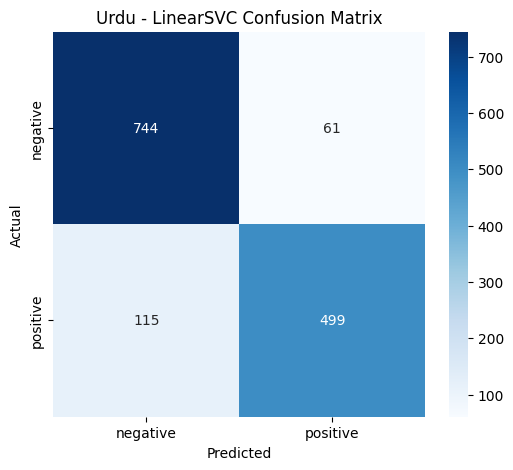

In [5]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # Import joblib for loading the pkl file

# -------------------------------------------------
# 1. Urdu
# -------------------------------------------------

# Load the TF-IDF vectorizer
tfidf_vectorizer = joblib.load('urdu_tfidf.pkl')

# Prepare data from urdu_df (assuming urdu_df is already loaded in the notebook)
X = tfidf_vectorizer.transform(urdu_df['comment'])

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(urdu_df['sentiment'])

# Split the data into training and testing sets
X_urdu_train, X_urdu_test, y_urdu_train, y_urdu_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Important for imbalanced datasets
)

svc_urdu = LinearSVC()
svc_urdu.fit(X_urdu_train, y_urdu_train)

y_urdu_pred = svc_urdu.predict(X_urdu_test)

print("========== URDU - LINEAR SVC ==========")
print("Accuracy :", accuracy_score(y_urdu_test, y_urdu_pred))
print("Precision:", precision_score(y_urdu_test, y_urdu_pred, average="weighted"))
print("Recall   :", recall_score(y_urdu_test, y_urdu_pred, average="weighted"))
print("F1 Score :", f1_score(y_urdu_test, y_urdu_pred, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_urdu_test, y_urdu_pred))

# Confusion Matrix
cm_urdu = confusion_matrix(y_urdu_test, y_urdu_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_urdu,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_, # Use actual class names for xticklabels
    yticklabels=label_encoder.classes_  # Use actual class names for yticklabels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Urdu - LinearSVC Confusion Matrix")
plt.show()

In [6]:
from google.colab import files
uploaded = files.upload()

Saving roman_urdu_tfidf.pkl to roman_urdu_tfidf.pkl


In [7]:
from google.colab import files
uploaded = files.upload()

Saving final_roman_urdu_dataset.csv to final_roman_urdu_dataset.csv


In [8]:
import pandas as pd

urdu_df = pd.read_csv("final_roman_urdu_dataset.csv")

print(urdu_df.head())
print(urdu_df.columns)

                                             comment sentiment Unnamed: 2  \
0  sai kha ya her kisi kay bus ki bat nhi hai lak...  positive        NaN   
1                                      sahi but haan  positive        NaN   
2                                        kya but hai  positive        NaN   
3                                         wah je wah  positive        NaN   
4                               are wha kaya bat hai  positive        NaN   

                                              tokens  
0  ['sai', 'kha', 'ya', 'her', 'kisi', 'kay', 'bu...  
1                            ['sahi', 'but', 'haan']  
2                              ['kya', 'but', 'hai']  
3                               ['wah', 'je', 'wah']  
4               ['are', 'wha', 'kaya', 'bat', 'hai']  
Index(['comment', 'sentiment', 'Unnamed: 2', 'tokens'], dtype='object')


========== ROMAN URDU - LINEAR SVC ==========
Accuracy : 0.7867256637168142
Precision: 0.7877622698813985
Recall   : 0.7867256637168142
F1 Score : 0.7869181193718091

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.78      1057
           1       0.81      0.78      0.80      1203

    accuracy                           0.79      2260
   macro avg       0.79      0.79      0.79      2260
weighted avg       0.79      0.79      0.79      2260



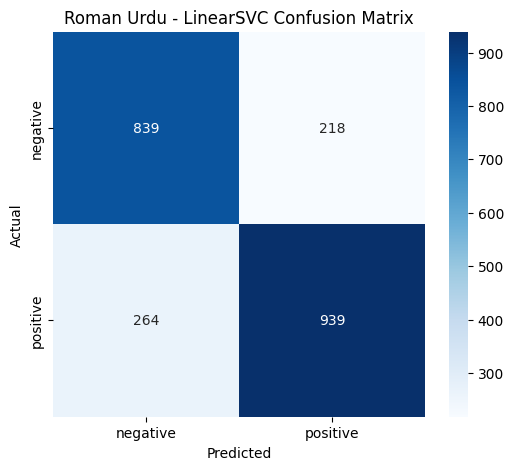

In [11]:
# ==============================
# LINEAR SVC - URDU + ROMAN URDU
# ==============================

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # Import joblib for loading the pkl file

# Load the TF-IDF vectorizer for Roman Urdu
roman_tfidf_vectorizer = joblib.load('roman_urdu_tfidf.pkl')

# Prepare data from urdu_df (assuming urdu_df is now loaded with Roman Urdu data)
# Use a new variable name for clarity if urdu_df is reused for different languages
roman_urdu_df = urdu_df.copy() # Make a copy to avoid modifying the original if it's meant for Urdu

# Handle NaN values in the 'comment' column by filling them with an empty string
roman_urdu_df['comment'] = roman_urdu_df['comment'].fillna('')

X_roman = roman_tfidf_vectorizer.transform(roman_urdu_df['comment'])

# Encode target labels for Roman Urdu
label_encoder_roman = LabelEncoder()
y_roman = label_encoder_roman.fit_transform(roman_urdu_df['sentiment'])

# Split the data into training and testing sets for Roman Urdu
X_roman_train, X_roman_test, y_roman_train, y_roman_test = train_test_split(
    X_roman,
    y_roman,
    test_size=0.2,
    random_state=42,
    stratify=y_roman # Important for imbalanced datasets
)


svc_roman = LinearSVC()
svc_roman.fit(X_roman_train, y_roman_train)

y_roman_pred = svc_roman.predict(X_roman_test)

print("========== ROMAN URDU - LINEAR SVC ==========")
print("Accuracy :", accuracy_score(y_roman_test, y_roman_pred))
print("Precision:", precision_score(y_roman_test, y_roman_pred, average="weighted"))
print("Recall   :", recall_score(y_roman_test, y_roman_pred, average="weighted"))
print("F1 Score :", f1_score(y_roman_test, y_roman_pred, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_roman_test, y_roman_pred))

# Confusion Matrix
cm_roman = confusion_matrix(y_roman_test, y_roman_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_roman,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder_roman.classes_, # Use actual class names for xticklabels
    yticklabels=label_encoder_roman.classes_  # Use actual class names for yticklabels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Roman Urdu - LinearSVC Confusion Matrix")
plt.show()

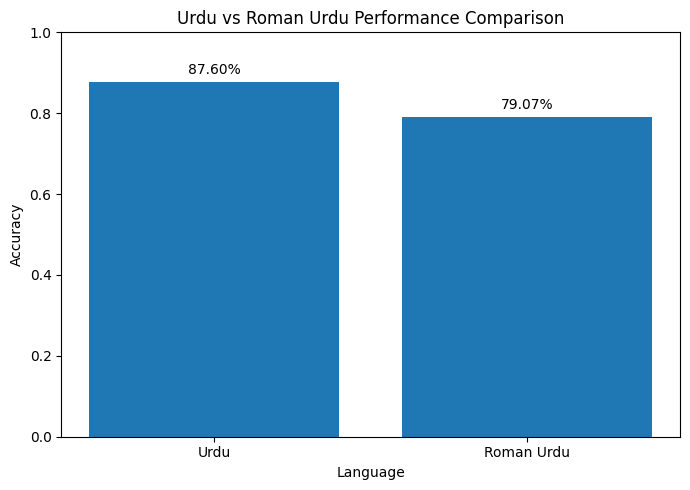

In [12]:
import matplotlib.pyplot as plt

languages = ["Urdu", "Roman Urdu"]
accuracy = [0.8760, 0.7907]

plt.figure(figsize=(7,5))

bars = plt.bar(languages, accuracy)

plt.ylabel("Accuracy")
plt.xlabel("Language")
plt.title("Urdu vs Roman Urdu Performance Comparison")
plt.ylim(0, 1)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.02,
        f"{value*100:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [13]:
print([name for name in globals() if "svc" in name.lower()])

['LinearSVC', 'svc_urdu', 'svc_roman']


In [14]:
import joblib

joblib.dump(svc_urdu, "urdu_linear_svc.pkl")
joblib.dump(svc_roman, "roman_urdu_linear_svc.pkl")

print("Both LinearSVC models saved successfully!")

Both LinearSVC models saved successfully!
